# Equal interaction magnitudes, different sign–magnitude organization

The main comparison uses the complete 289-SPI catalogue: raw off-diagonal MPI means $m$ versus signed Pearson SPI–SPI $z$. Distribution summaries are secondary. These are deliberately constructed Gaussian controls, not a benchmark of general superiority or nonlinear dynamics.

The preceding band-swap experiment failed: its full mean vector and SPI–SPI both classified every development validation recording. Squared lagged-correlation means exposed residual temporal-strength differences. That executed negative report is retained as `spi_band_swap_261004.ipynb`; its held set remains unopened. Here temporal dependence is removed and interaction magnitudes are matched more strongly.

**Development result.** MPI means: **46.9%**; full means: **54.7%**; RBF means: **45.3%**; tree means: **51.6%**; centered SPI–SPI: **68.8%**. Chance is 50%. The original standardized SPI–SPI readout scores 64.1%. The frozen development gate was not met; these are development results, not held confirmation.

**More independent recordings, fixed $T=1000$.** The user capped observation length at 1,000. An exploratory grouped learning-curve check reused all previously examined T1000 recordings: centered z averaged .6875/.6602/.7266 with 32/64/96 training recordings, respectively, while mean readouts remained near .5. This provides modest motivation for a larger training bank, not a prediction of success. The covariance and centered PCA20/linear readout remain fixed. This experiment uses 192 development-training recordings, 64 validation recordings and 128 held recordings, from entirely fresh RNG blocks 256–447. No new held outcomes choose a generator, readout or figure. The refinement history described below concerns the earlier T1000 experiment; its selected readout was fixed before this replication.

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent:ROOT=ROOT.parent
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from scripts.build_factor_parity import covariance,CLASSES
from scripts.plot_band_swap import plot
RUN='factor-parity-replication-261004';STAGE='development'
OUT=ROOT/'results/representation'/RUN
RESULT=OUT/STAGE
metrics=pd.read_csv(RESULT/'metrics.csv')
analysis=json.loads((RESULT/'analysis.json').read_text())
display(metrics[metrics.method.isin(['mean','mean_full','mean_RBF','mean_trees','z_center','z'])].round(3))

,method,n,BA,low,high,chance
4,mean,64,0.469,0.359,0.578,0.5
6,z,64,0.641,0.516,0.766,0.5
11,z_center,64,0.688,0.562,0.812,0.5
15,mean_full,64,0.547,0.438,0.656,0.5
16,mean_RBF,64,0.453,0.359,0.547,0.5
17,mean_trees,64,0.516,0.391,0.641,0.5


In [2]:
display(pd.read_csv(ROOT/'results/representation/factor-sample-size-261004/summary.csv').round(3))

,training_recordings,method,mean,min,max
0,32,mean,0.527,0.375,0.625
1,32,mean_RBF,0.504,0.438,0.594
2,32,mean_full,0.531,0.438,0.625
3,32,mean_trees,0.500,0.375,0.625
4,32,z_center,0.688,0.594,0.781
5,32,z_full_center,0.664,0.594,0.750
6,64,mean,0.523,0.406,0.656
7,64,mean_RBF,0.516,0.438,0.625
8,64,mean_full,0.547,0.500,0.625
9,64,mean_trees,0.512,0.406,0.656


## Generator and strength control

Let $f_{at}$ and $\epsilon_{it}$ be independent standard Gaussian variables across factors, channels and time. A recording has 16 channels and 1,000 observations, with

$$x_{it}=\sqrt{1-\lambda}\,\epsilon_{it}+\sqrt{\lambda}\sum_{a=1}^3\sqrt{w_a}\,v_{ai}f_{at},\qquad \lambda=.25,\quad w=(.9,.075,.025).$$

Equivalently, $x_t\sim N(0,C)$ independently in time, where $C=(1-\lambda)I+\lambda\sum_a w_a v_av_a^\top$. The implementation samples this covariance by a Cholesky transform. The private variance is .75 and total shared-factor variance .25; the weights divide the latter between factors. These describe **functional dependence through shared inputs**, not direct causal channel-to-channel coupling.

Channels are indexed by four binary bits. The first two sign vectors are $v_{1i}=(-1)^{b_1(i)}$ and $v_{2i}=(-1)^{b_2(i)}$. In the **linked-signs** class, $v_3=v_1v_2$ elementwise; in the **unlinked-signs** class, $v_{3i}=(-1)^{b_3(i)}$. In both classes the three vectors are balanced and mutually orthogonal. A fresh channel permutation accompanies each recording.

Both classes have unit population channel variance, identical covariance eigenvalues, the same complete multiset of off-diagonal absolute correlations, and identical positive/negative edge counts. Every channel has total absolute off-diagonal covariance 3.35; mean absolute coupling is $3.35/15=.223\overline3$, and mean signed coupling is $-.25/15=-.016\overline6$. All nonzero-lag population covariances vanish. These equalities hold at the generator level; empirical estimates fluctuate between recordings. No MPI normalization or whitening is applied afterward.

For a temporally iid Gaussian pair, reversing one channel changes only the sign of its correlation. Consequently every sign-invariant bivariate population SPI has the same off-diagonal value multiset in the two classes. **Signed distributions, sign-sensitive nonlinear statistics, multivariate estimators and finite-sample aggregate laws need not match.** This is a claim about specified functional strengths, not a universal coupling metric.

In [3]:
mask=~np.eye(16,dtype=bool)
checks=[]
for label in CLASSES:
    C=covariance(label,.25,[.9,.075,.025]);r=C[mask]
    checks.append(dict(label=label,mean=r.mean(),mean_absolute=np.abs(r).mean(),mean_square=np.mean(r*r),mean_cube=np.mean(r**3),mean_ED=np.sqrt(2-2*r).mean(),negative_fraction=np.mean(r<0),z_linear_square=np.corrcoef(r,r*r)[0,1]))
display(pd.DataFrame(checks).round(6))

,label,mean,mean_absolute,mean_square,mean_cube,mean_ED,negative_fraction,z_linear_square
0,linked-signs,-0.016667,0.223333,0.05025,-0.000873,1.417046,0.533333,-0.018288
1,unlinked-signs,-0.016667,0.223333,0.05025,-0.001042,1.417063,0.533333,-0.105422


## Why these parameters?

The first factor is dominant so that sign counts match and regularized covariance/precision estimates have more stable sign patterns. The initial factor candidate (.35; weights .7/.2/.1) was rejected before any p90 computation because graphical-lasso means differed even at population level. Five stronger-dominance/lower-strength settings were checked using cheap statistics on development blocks, followed by five more when those retained mean information. The selected setting was candidate 8: the weakest worst mean readout among candidates with nearly equal population graphical-lasso means and probe-z accuracy at least .8. Its cheap mean classifiers scored .5625/.6875/.5 versus .875 for probe z on 16 validation recordings.

This is openly **development-based experimental design**, not preregistration of the entire search. No full-p90 or held results selected these parameters. All scout outcomes are retained below. The complete catalogue and a separate held set are required to assess whether that promising cheap result survives.

In [4]:
display(pd.read_csv(ROOT/'results/representation/factor-parity-261004/scout-results.csv').round(4))

,candidate,strength,weights,population_GL_mean_gap,mean_linear,mean_rbf,mean_trees,z_linear
0,0,0.35,"[0.8, 0.15, 0.05]",0.0003,1.0000,1.0000,1.0000,1.0000
1,1,0.25,"[0.7, 0.2, 0.1]",0.0083,1.0000,1.0000,1.0000,1.0000
2,2,0.20,"[0.7, 0.2, 0.1]",0.0080,1.0000,1.0000,1.0000,0.9375
3,3,0.30,"[0.8, 0.15, 0.05]",0.0000,0.9375,0.9375,1.0000,0.9375
4,4,0.35,"[0.85, 0.1, 0.05]",0.0000,0.8750,0.8750,0.8125,0.9375
5,5,0.20,"[0.85, 0.1, 0.05]",0.0000,0.7500,0.6875,0.6250,0.8750
6,6,0.25,"[0.85, 0.1, 0.05]",0.0000,0.8750,0.7500,0.6875,0.9375
7,7,0.35,"[0.9, 0.075, 0.025]",0.0000,0.8125,0.6875,0.6250,0.9375
8,8,0.25,"[0.9, 0.075, 0.025]",0.0000,0.5625,0.6875,0.5000,0.8750
9,9,0.30,"[0.9, 0.075, 0.025]",0.0000,0.6875,0.6875,0.6250,0.8750


## Full-catalogue comparison

Training uses development blocks 0–95, validation blocks 96–127; each block contains both classes. The separate held blocks 128–191 are evaluated only after a documented development decision, using training blocks 0–127. Training-only preprocessing selects 95% finite features and imputes medians. Means/distributions use SD scaling, clipping at five SD and 20 PCs; the preferred SPI–SPI readout centers correlations without rescaling or clipping, then uses 20 PCs. Logistic regression fixes $C=1$. Full-mean logistic, RBF and tree readouts test whether a PCA/linear bottleneck hides mean information. Distributions contain mean, SD and 10/25/50/75/90 percentiles per SPI.

**Readout refinement before confirmation.** The initial standardized full-catalogue z readout scored .625 on development, failing the target despite weak means (.4375–.625). Center-only z, as used in the earlier proof analysis, scored .8125 with the same 20 PCs and linear classifier; features already share a correlation scale, so there is no unit-conversion reason to standardize them individually. An exploratory audit retained both scalings, PCA20/full features and linear/RBF results; the center-only PCA20 linear model was selected for confirmation, not the highest-scoring RBF model. This choice was made after seeing development outcomes and frozen in `factor-parity-dominant-261004-confirmation.yaml` before releasing any held MPI. The original standardized result remains reported. A secondary training-complete z subset and edge-shuffled control use the same centered preprocessing.

The figures use fixed PCA/UMAP settings and training-fit/evaluation-transform, without searching seeds or selecting points. Numerical performance takes precedence over appearance. Conditional bootstrap intervals resample paired recording blocks, keeping fitted models fixed; they omit training and parameter-selection uncertainty. Near-chance finite-sample performance is not proof of information-theoretic absence.

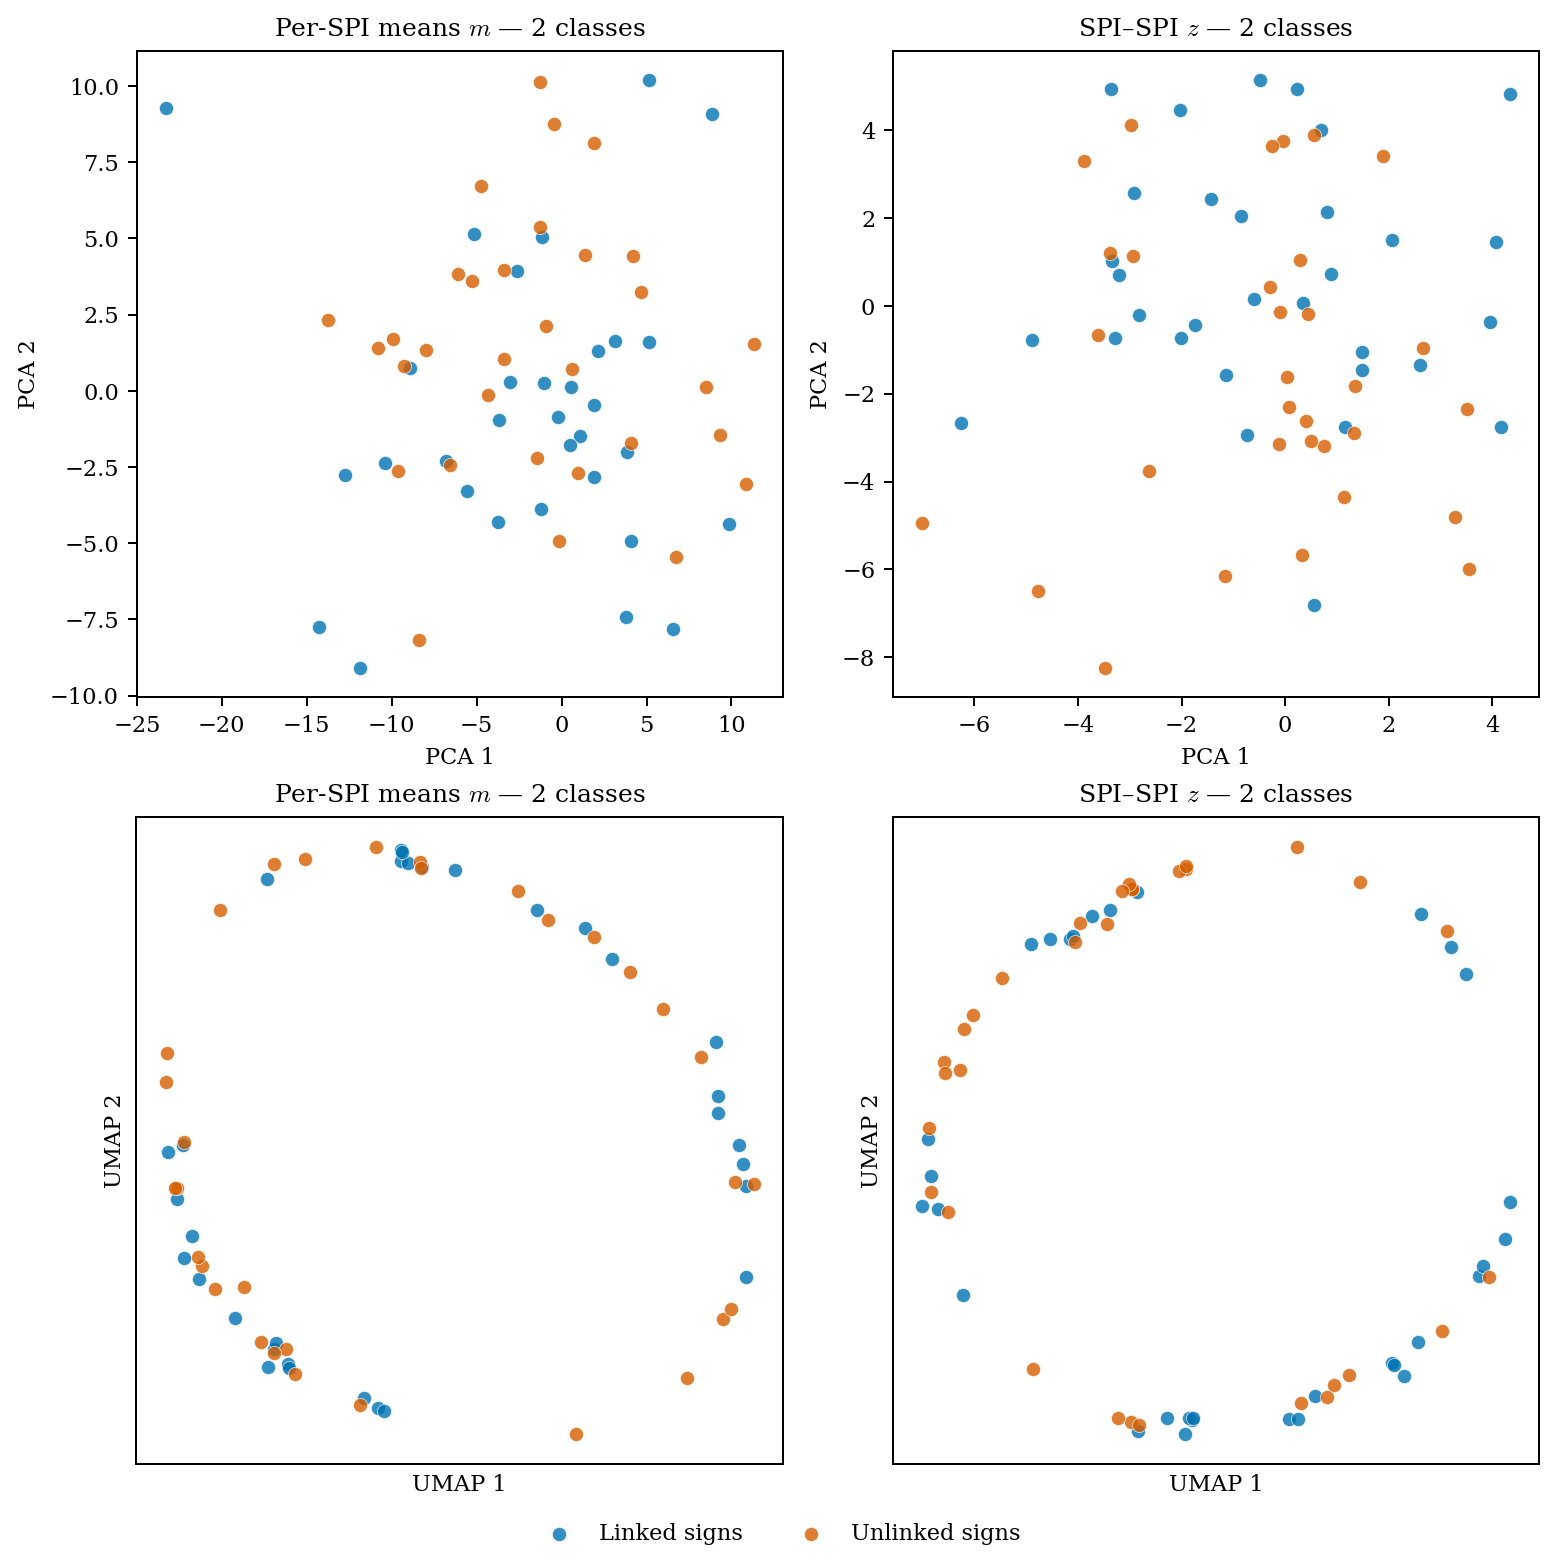

,comparison,difference,low,high
23,z_center - mean,0.219,0.078,0.375
24,z_center - mean_full,0.141,0.000,0.281
25,z_center - mean_RBF,0.234,0.062,0.406
26,z_center - mean_trees,0.172,-0.016,0.359
27,z_center - distribution,0.062,-0.062,0.203
28,z_center - z_shuffled_center,0.219,0.047,0.391


,method,n,BA,low,high,chance
5,distribution,64,0.625,0.516,0.734,0.5
7,z_validity,64,0.516,0.391,0.641,0.5
12,z_center_complete,64,0.688,0.562,0.812,0.5
13,z_shuffled_center,64,0.469,0.344,0.594,0.5


In [5]:
plot(STAGE,focused=False,run=RUN,z_method='z_center');plt.show()
paired=pd.read_csv(RESULT/'paired.csv')
display(paired[paired.comparison.str.startswith('z_center - ')].round(3))
display(metrics[metrics.method.isin(['distribution','z_validity','z_shuffled_center','z_center_complete'])].round(3))

## Mechanism and limits

The classes differ in how signs associate with interaction magnitudes, even though their mean signed strength and entire absolute-strength distribution agree. A pair such as covariance versus squared covariance can respond to this association. For the selected population matrices, that z value is approximately −.0183 versus −.1054. Its numerator is $E[r^3]-E[r]E[r^2]$ across edges; the first, second and fourth moments agree between classes, while the third differs. This is not evidence of nonlinear dynamics: both models are Gaussian. Since the second probe is a function of the first, this particular feature also reflects the shape of the signed covariance distribution. It cannot establish information inaccessible to every marginal-distribution description.

Not every population MPI mean is identical either. With unit channel variances, population root-mean-square Euclidean distance is $\sqrt{2-2r}$ per edge. Its mean is 1.41704644 versus 1.41706254, a difference of about $1.61\times10^{-5}$. A weak finite-data mean classifier is therefore not proof that its input has zero class information.

The validity-only control uses missingness without numerical z values. The independently shuffled-edge control preserves every MPI marginal while removing alignment; it is a diagnostic transformation, not a realizable-MTS claim. Any class information in these controls must qualify the interpretation. Means of the full catalogue are not inherently blind to dependence character, so informative means would constitute another negative result for the proposed picture.

In [6]:
display(metrics[metrics.method.isin(['probe_mean','probe_z','raw_covariance','raw_Pearson'])].round(3))
display(pd.read_csv(RESULT/'diagnostic-features.csv').round(3))
display(pd.DataFrame(analysis['diagnostics']).T.round(3))

,method,n,BA,low,high,chance
0,probe_mean,64,0.562,0.453,0.656,0.5
1,probe_z,64,0.891,0.812,0.953,0.5
2,raw_covariance,64,0.766,0.656,0.859,0.5
3,raw_Pearson,64,0.797,0.703,0.891,0.5


,method,training_rank,feature,training_standardized_difference,evaluation_AUC
0,mean,1,cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5,-0.351,0.522
1,mean,2,cohmag_multitaper_max_fs-1_fmin-0_fmax-0-5,-0.348,0.416
2,mean,3,dspli_multitaper_mean_fs-1_fmin-0_fmax-0-5,-0.337,0.439
3,mean,4,corr_kendall_tau-1,0.326,0.499
4,mean,5,corr_spearman_tau-1,0.318,0.496
5,mean,6,dspli_multitaper_mean_fs-1_fmin-0_fmax-0-25,-0.298,0.444
6,mean,7,cov-sq_EllipticEnvelope,-0.290,0.545
7,mean,8,cov-sq_MinCovDet,-0.290,0.545
8,mean,9,prec_GraphicalLassoCV,0.282,0.495
9,mean,10,corr_kendall_tau-2-sq,-0.281,0.515


,selected_features,components,explained_variance,evaluation_selected_missing_fraction
probe_mean,10.0,10.0,1.000,0.0
probe_z,36.0,20.0,1.000,0.0
raw_covariance,7.0,7.0,1.000,0.0
raw_Pearson,7.0,7.0,1.000,0.0
mean,265.0,20.0,0.760,0.0
distribution,1870.0,20.0,0.599,0.0
z,33513.0,20.0,0.311,0.0
z_validity,2725.0,20.0,1.000,0.0
z_shuffled,35778.0,20.0,0.110,0.0
z_complete,33513.0,20.0,0.311,0.0


The protocol is `configs/analysis/factor-parity-replication-261004.yaml`; `build_factor_parity.py` constructs the immutable raw bank. `analyze_band_swap.py --run factor-parity-replication-261004` audits input/member/catalogue/RNG provenance, extracts features and evaluates the fixed readouts. `sources.json` binds MPI hashes; `execution.json` records cluster jobs and the held-release decision. Rendering uses cached outputs and does not recompute SPIs.

In [7]:
print(json.dumps(analysis.get('centered_development_goal',{}),indent=2))
print(json.dumps(json.loads((OUT/'execution.json').read_text()),indent=2))

{
  "mean_readouts_weak": true,
  "z_detectable": false,
  "validity_weak": true,
  "all_pass": false,
  "qualification": "Center-only z refinement selected after initial development result; requires untouched held confirmation"
}
{
  "stage": "complete development experiment; fixed gate failed; executed report saved; no held release",
  "run": "factor-parity-replication-261004",
  "held_released": false,
  "development_records": 256,
  "held_records": 128,
  "T": 1000,
  "M": 16,
  "archive_sha256": "2c168cc7b57d1524830f286c7b61a630f391285cbda8945e951c9605ddeb09f9",
  "jobs": {
    "smoke": "180445480.gadi-pbs",
    "node_gate": "180445629.gadi-pbs",
    "development_remaining": "180446116.gadi-pbs"
  },
  "validation": "384 manifest rows; T1000; fresh RNG256\u2013447; 8 development raw inputs independently replay exactly; frozen readout bindings verified",
  "compute_plan": "2-row smoke then48core node gate then remaining development; held indices257\u2013384 sealed until frozen deve

## Development diagnosis after the fixed readout failed

Increasing independent training recordings did not deliver the prespecified strong-z result. A separate development-only audit tested PCA20 versus all features, linear versus RBF classifiers, and both z scalings; means received the corresponding PCA/full and linear/RBF comparisons. The primary centered PCA20 linear result remains .6875. All-feature centered linear z reaches .78125, while centered PCA20 RBF is .640625. No tested variant reaches .8, so the 128 held recordings remain unevaluated. The diagnostic does not replace the failed primary result.

The fixed full-catalogue PCA/UMAP plots remain substantially mixed; ring-like layouts occur for both representations and are not class separation. The narrow probe catalogue is more discriminative (.890625), but this cannot establish the full-catalogue target. Raw covariance/Pearson distribution summaries score .765625/.796875, supporting the stated limit of the mean-compression comparison.

Reusing development scores to choose an analysis can create optimistic estimates; these diagnostics are exploratory, and any later chosen readout needs untouched confirmation ([Cawley and Talbot, 2010](https://www.jmlr.org/papers/v11/cawley10a.html)). The present evidence does not establish either a clean unsupervised embedding or information absent from every marginal description.

In [8]:
display(pd.read_csv(RESULT/'readout-audit.csv').round(4))

,method,BA
0,mean_standard_20_linear,0.4688
1,mean_standard_20_rbf,0.4688
2,mean_standard_full_linear,0.5469
3,mean_standard_full_rbf,0.4531
4,z_center_20_linear,0.6875
5,z_center_20_rbf,0.6406
6,z_center_full_linear,0.7812
7,z_center_full_rbf,0.6875
8,z_standard_20_linear,0.6406
9,z_standard_20_rbf,0.6094
